In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [19]:
df = sns.load_dataset('healthexp')
df.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


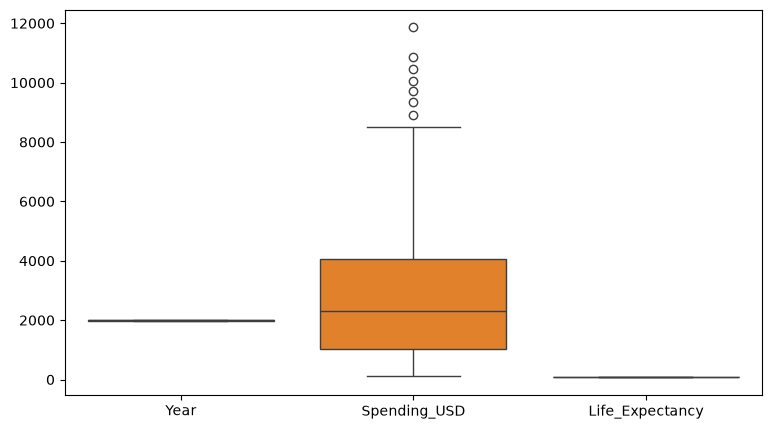

In [20]:
plt.figure(figsize=(9,5))
sns.boxplot(df)
plt.show()

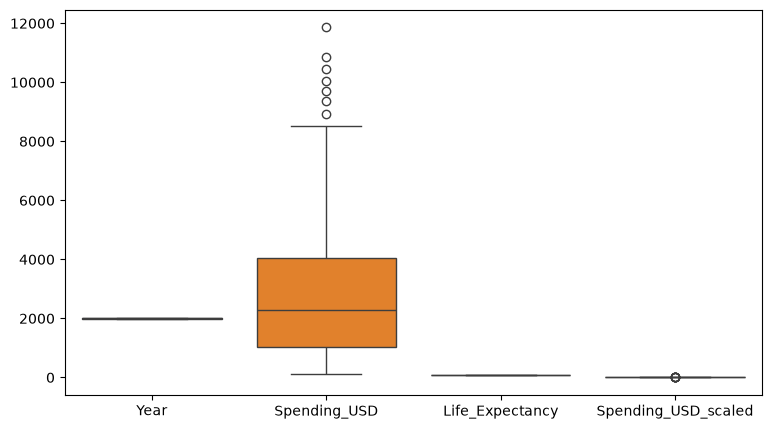

In [21]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df['Spending_USD_scaled'] = scaler.fit_transform(df[['Spending_USD']])
plt.figure(figsize=(9,5))
sns.boxplot(df)
plt.show()

In [22]:
df.head()

,Year,Country,Spending_USD,Life_Expectancy,Spending_USD_scaled
0,1970,Germany,252.311,70.6,-0.677194
1,1970,France,192.143,72.2,-0.697136
2,1970,Great Britain,123.993,71.9,-0.719723
3,1970,Japan,150.437,72.0,-0.710958
4,1970,USA,326.961,70.9,-0.652453


In [23]:
df.drop(columns=['Spending_USD'], inplace=True)
df.head()

,Year,Country,Life_Expectancy,Spending_USD_scaled
0,1970,Germany,70.6,-0.677194
1,1970,France,72.2,-0.697136
2,1970,Great Britain,71.9,-0.719723
3,1970,Japan,72.0,-0.710958
4,1970,USA,70.9,-0.652453


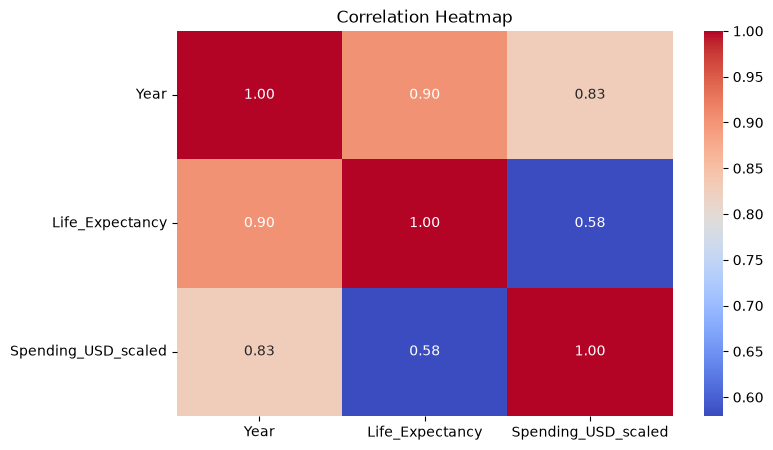

In [24]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

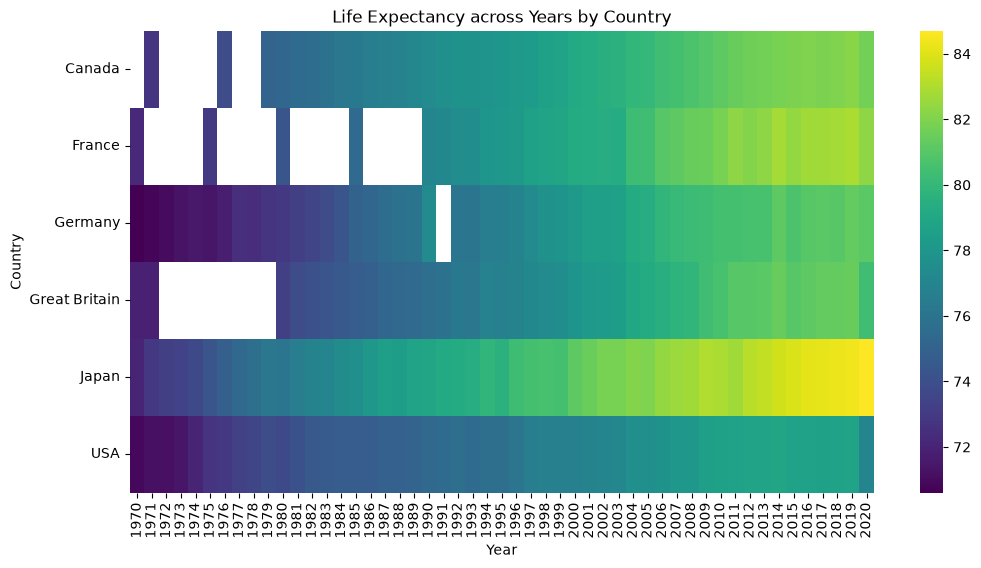

In [10]:
pivot_df = df.pivot(index='Country', columns='Year', values='Life_Expectancy')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_df, cmap='viridis')
plt.title("Life Expectancy across Years by Country")
plt.show()

In [11]:
df.isnull().sum()

Year                   0
Country                0
Life_Expectancy        0
Spending_USD_scaled    0
dtype: int64

In [12]:
# 1. Feature (X) aur Target (Y) ko NumPy array me convert karein
X = df['Year'].values
Y = df['Life_Expectancy'].values

# 2. X aur Y ka Mean calculate karein
x_mean = np.mean(X)
y_mean = np.mean(Y)

# 3. Slope (m) calculate karein (Numerator aur Denominator)
numerator = np.sum((X - x_mean) * (Y - y_mean))
denominator = np.sum((X - x_mean) ** 2)
m = numerator / denominator

# 4. Intercept (c) calculate karein
c = y_mean - (m * x_mean)

print(f"Slope (m): {m:.4f}")
print(f"Intercept (c): {c:.4f}")
print(f"Regression Equation: Y = {m:.4f} * X + ({c:.4f})")

Slope (m): 0.2084
Intercept (c): -338.3279
Regression Equation: Y = 0.2084 * X + (-338.3279)


In [13]:
# 5. Prediction (Y_pred = m*X + c)
Y_pred = m * X + c

# 6. R2 Score (Manual calculation)
ss_total = np.sum((Y - y_mean) ** 2)
ss_residual = np.sum((Y - Y_pred) ** 2)
r2_score = 1 - (ss_residual / ss_total)

print(f"R² Score: {r2_score:.4f}")

R² Score: 0.8139


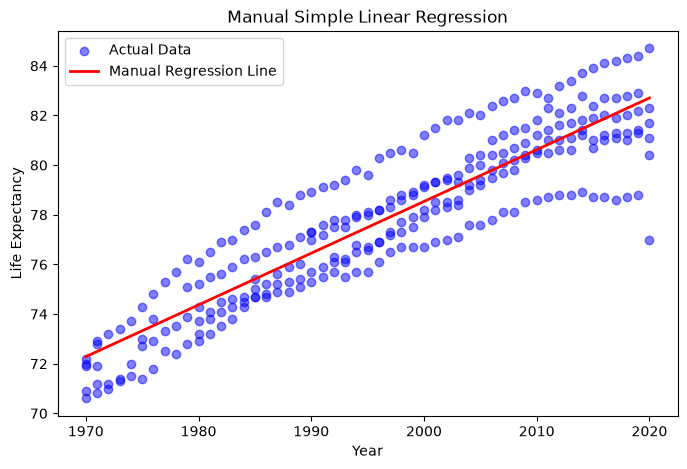

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Manual Regression Line')
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.title('Manual Simple Linear Regression')
plt.legend()
plt.show()

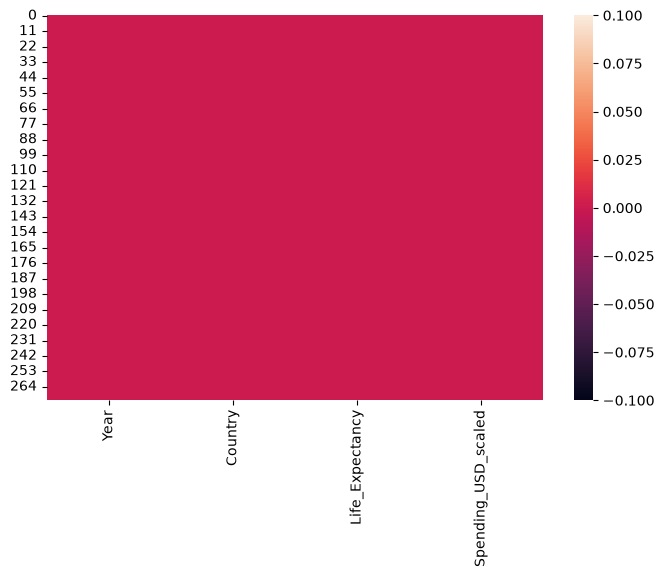

In [15]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull())
plt.show()